In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
housing=pd.read_csv("cloud.csv")

In [3]:
# Affichage des 5 premières lignes
housing.head(5)

,id_maison,quartier,surface_m2,nb_chambres,annee_construction,etat_general,proche_ecole,prix_vente
0,1000,Sud,56,1.0,1970,3.0,1,148851
1,1001,Ouest,57,2.0,200,1.0,0,116462
2,1002,Sud,44,2.0,2011,3.0,0,115593
3,1003,Sud,56,2.0,1953,2.0,1,161971
4,1004,Sud,93,4.0,1984,4.0,1,271092


In [4]:
# Types des colonnes
housing.dtypes

id_maison               int64
quartier               object
surface_m2              int64
nb_chambres           float64
annee_construction      int64
etat_general          float64
proche_ecole            int64
prix_vente              int64
dtype: object

In [5]:
# Statistiques descriptives
housing.describe()

,id_maison,surface_m2,nb_chambres,annee_construction,etat_general,proche_ecole,prix_vente
count,5000.000000,5000.000000,4848.000000,5000.000000,4766.000000,5000.00000,5000.000000
mean,3499.500000,70.306000,2.419554,1980.899800,5.512799,0.50060,196155.061200
std,1443.520003,24.842878,1.156125,165.764135,2.857611,0.50005,86564.137613
min,1000.000000,15.000000,1.000000,200.000000,1.000000,0.00000,-825.000000
25%,2249.750000,53.000000,1.000000,1968.000000,3.000000,0.00000,135529.250000
50%,3499.500000,71.000000,2.000000,1987.000000,6.000000,1.00000,190000.000000
75%,4749.250000,87.000000,3.000000,2006.000000,8.000000,1.00000,248436.250000
max,5999.000000,152.000000,7.000000,2999.000000,10.000000,1.00000,603028.000000


In [6]:
# pourcentage de valeurs manquantes
housing.isna().mean()*100

id_maison             0.00
quartier              0.00
surface_m2            0.00
nb_chambres           3.04
annee_construction    0.00
etat_general          4.68
proche_ecole          0.00
prix_vente            0.00
dtype: float64

In [7]:
# remplacement des valeurs manquantes de surface_m2 par la median
housing["surface_m2"].fillna(
    housing["surface_m2"].median(),
    inplace=True
)

C:\Users\itomo\AppData\Local\Temp\ipykernel_12996\144664129.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["surface_m2"].fillna(


In [8]:
# remplacement des valeurs manquantes par 5
housing["etat_general"] = housing["etat_general"].fillna(5)

In [9]:
# supprimer les lignes ou le prix de vente est manquant
housing = housing.dropna(subset=["prix_vente"])
housing.shape

(5000, 8)

In [10]:

#enlever les surfaces inferieurs à 9m2
housing = housing[housing["surface_m2"] > 9]
housing.shape

(5000, 8)

In [11]:
housing= housing[housing["annee_construction"]>1900]
housing= housing[housing["annee_construction"]<2026]
housing.shape

(4892, 8)

In [12]:
# identification des prix en dessus de 20000 considerer comme trop bas
housing[housing['prix_vente']<20000].value_counts().sum() # resultat 48
# supprimer les lignes
housing=housing[housing['prix_vente']>20000]
housing.shape

(4844, 8)

### Partie 2 : Feature engineering

In [13]:
# creation d'une colonne age_bien
housing["age_bien"] = 2026 - housing["annee_construction"]
# supprimer la colonne annee_construction
housing.drop(columns=["annee_construction"], inplace=True)

In [14]:
# categorisation de la surface
housing["classe_surface"] = pd.cut(
    housing["surface_m2"],
    bins=[0, 50, 100, housing["surface_m2"].max() + 1],  # <-- +1 important
    labels=["Petit", "Moyen", "Grand"],
    right=False
)

housing["classe_surface"].value_counts()


classe_surface
Moyen    3281
Petit     977
Grand     586
Name: count, dtype: int64

In [15]:
# creation de colonnee prix_m2
housing["prix_m2"] = housing["prix_vente"] / housing["surface_m2"]


In [16]:
# calcul du prix moyen
prix_m2_quartier = (
    housing
    .groupby("quartier")["prix_m2"]
    .mean()
)
# classification

prix_m2_quartier.sort_values(ascending=False)


quartier
Centre    3614.501485
Sud       2846.979525
Ouest     2572.166769
Nord      2261.562342
Name: prix_m2, dtype: float64

In [17]:
# Sélection des variables numériques
variables_numeriques = housing.select_dtypes(include=["int64", "float64"])

# Calcul de la matrice de corrélation
corr_matrix = variables_numeriques.corr()

corr_matrix


,id_maison,surface_m2,nb_chambres,etat_general,proche_ecole,prix_vente,age_bien,prix_m2
id_maison,1.000000,-0.003520,-0.008956,0.003622,-0.001452,-0.006493,-0.000632,-0.014306
surface_m2,-0.003520,1.000000,0.706829,-0.018733,-0.024588,0.806958,-0.017147,-0.029817
nb_chambres,-0.008956,0.706829,1.000000,-0.005426,-0.014315,0.574230,0.009505,-0.013370
etat_general,0.003622,-0.018733,-0.005426,1.000000,0.005234,0.307865,-0.017268,0.555110
proche_ecole,-0.001452,-0.024588,-0.014315,0.005234,1.000000,-0.026649,-0.025250,-0.010915
prix_vente,-0.006493,0.806958,0.574230,0.307865,-0.026649,1.000000,-0.021789,0.525772
age_bien,-0.000632,-0.017147,0.009505,-0.017268,-0.025250,-0.021789,1.000000,-0.016212
prix_m2,-0.014306,-0.029817,-0.013370,0.555110,-0.010915,0.525772,-0.016212,1.000000


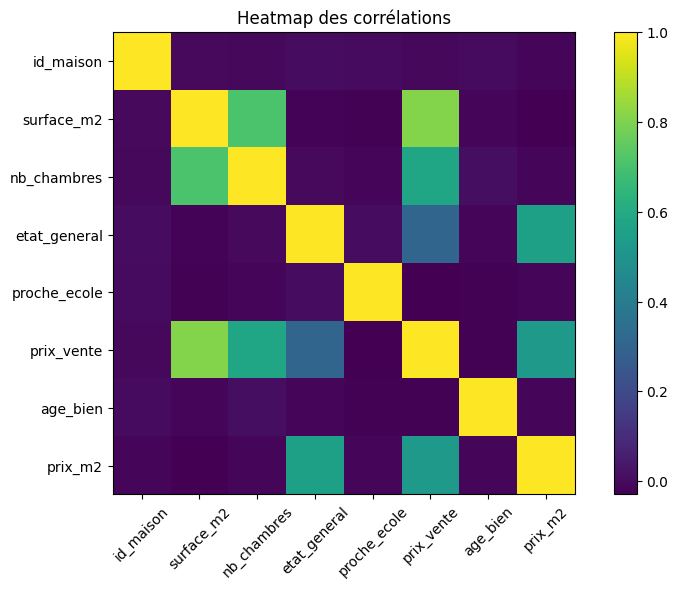

In [18]:
plt.figure(figsize=(10, 6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Heatmap des corrélations")
plt.show()


In [19]:
housing[["surface_m2", "nb_chambres", "prix_vente"]].corr()

,surface_m2,nb_chambres,prix_vente
surface_m2,1.000000,0.706829,0.806958
nb_chambres,0.706829,1.000000,0.574230
prix_vente,0.806958,0.574230,1.000000


In [20]:
#prix moyen national claculer en fesant la moyenne des prix de ventes
prix_moyen_national = housing["prix_vente"].mean()
maisons_filtrees = housing[
    (housing["nb_chambres"] > 4) &
    (housing["prix_vente"] < prix_moyen_national)
]
maisons_filtrees.value_counts().sum() # resultat 5

np.int64(5)

<Figure size 1000x600 with 0 Axes>

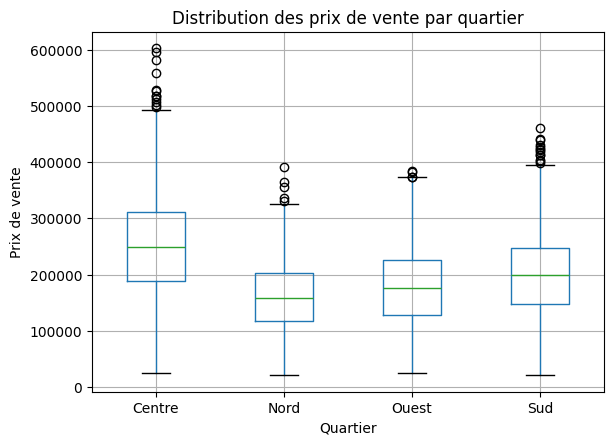

In [21]:
plt.figure(figsize=(10, 6))
housing.boxplot(column="prix_vente", by="quartier")
plt.title("Distribution des prix de vente par quartier")
plt.suptitle("")  # enlève le titre automatique
plt.xlabel("Quartier")
plt.ylabel("Prix de vente")
plt.show()

## interpretation
Le boxplot montre que le quartier Centre est le plus cher, avec la médiane de prix la plus élevée.
On observe également de fortes disparités de prix, notamment dans le quartier Centre, où plusieurs valeurs extrêmes sont présentes.

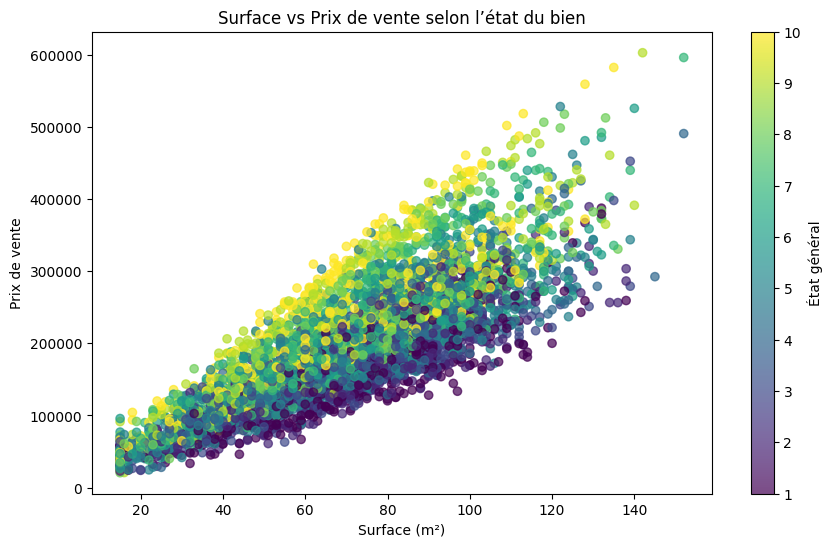

In [22]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    housing["surface_m2"],
    housing["prix_vente"],
    c=housing["etat_general"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(scatter, label="État général")
plt.xlabel("Surface (m²)")
plt.ylabel("Prix de vente")
plt.title("Surface vs Prix de vente selon l’état du bien")
plt.show()

# les logements en bon état (note élevée) sont plus chers
# les logements en mauvais état sont moins chers

- les logements en bon état (note élevée) sont plus chers

- les logements en mauvais état sont moins chers

- On voit des points de différentes hauteurs pour la même surface, selon la couleur.

## Machine learning

In [23]:
y = housing["prix_vente"]
housing["nb_chambres"] = housing["nb_chambres"].fillna(housing["nb_chambres"].median())
X = housing.drop(columns=["prix_vente"])
X = pd.get_dummies(X, drop_first=True)
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.2,random_state=5)é

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.01)
# Entraînement
lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [26]:
from sklearn.metrics import r2_score

# Prédictions
y_pred = lr.predict(X_test)

# Score R²
r2 = r2_score(y_test, y_pred)

r2


0.9552185006970757

In [27]:
comparaison = pd.DataFrame({
    "Prix réel": y_test.iloc[:5].values,
    "Prix prédit": y_pred[:5]
})

comparaison
print
print

,Prix réel,Prix prédit
0,485790,430636.254520
1,247933,257889.882374
2,259292,262281.705059
3,178453,186186.961611
4,292461,351923.309052


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred)